In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import utility
from sklearn.metrics import mean_squared_error
from importlib import reload
reload(utility)
import pickle
import os
import pandas as pd

In [2]:


#insurance_data=pd.read_csv("insurance.csv")
#y=insurance_data["charges"]
#X=insurance_data.drop(columns=["charges"])
#insurance_data
#variable=['sex','smoker','region']
#X=pd.get_dummies(data=X,prefix=variable,columns=variable)


In [4]:
#for dataset Housing 
X=pd.read_csv("Housing.csv")
y=X["price"]
X=X.drop(columns=["condition","price","date","id"],axis=1)


In [5]:




#y=X["price"]
#X=X.drop(columns=["condition","price","date","id"],axis=1)

In [6]:
#split data into train,test and validation data
x_train,x_,y_train,y_=train_test_split(X,y,test_size=0.40,random_state=1)
x_cv,x_test,y_cv,y_test=train_test_split(x_,y_,test_size=0.50,random_state=1)

In [7]:

baseline=3e10

[18946113854.933388, 11322470340.470417, 6447515951.354267, 2782926450.2661333],[22554630907.999554, 13644282865.013565, 40305334001.506836, 210304475393333.4]


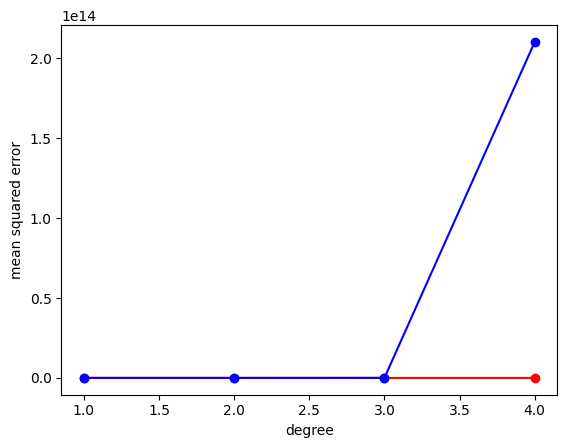

In [8]:
#define list of degree
degrees=[1,2,3,4]

         #find  optimal degree that best fit model
opt_degree,model,poly,scaler=utility.find_best_model(x_train,y_train,x_cv,y_cv,degrees,baseline)

In [9]:
#list of regularized parameter
regularized=[10, 5, 2, 1,0.5,0.1,0.01,0.001]

In [26]:
print(X.dtypes)

bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


train_mses=[14569767085.022268, 14431570114.34612, 14212006391.355398, 14008264406.10706, 13775905391.293587, 13142116044.426298, 11931859804.419743, 11422503475.887648]
cv_mses=[17364376010.431137, 17107871452.349133, 16748757153.662777, 16466527324.562847, 16184677961.880808, 15527840808.701273, 14274943736.403025, 13778064565.620205]


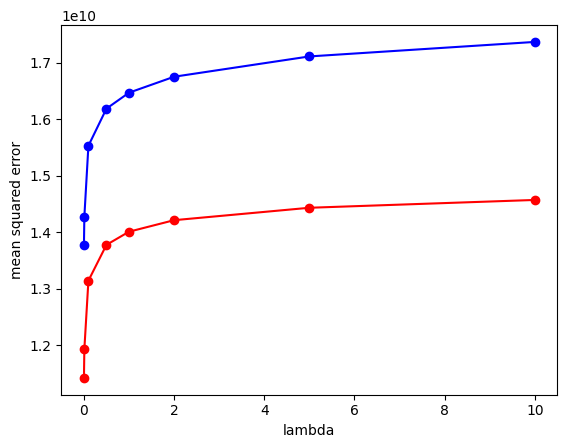

In [12]:
#find regularized parameter that best fit Ridge model
opt_lambda,model_ridge,polys,scaler=utility.find_regularized_parameter(x_train,y_train,x_cv,y_cv,opt_degree,regularized,baseline)

In [13]:
#Save the trained model as a pickle file for future predictions
pickle.dump(model_ridge,open("house_model.pkl","wb"))
pickle.dump(polys,open("house_polys.pkl","wb"))
pickle.dump(scaler,open("house_scaler.pkl","wb"))